# Preprocessing Experiments

Project:
Explainable AI-Powered Pneumonia Diagnosis & Clinical Decision Support System

Objectives:

- Evaluate preprocessing techniques
- Improve image quality
- Compare enhancement methods
- Select optimal preprocessing pipeline

In [1]:
import os
import random

import cv2
import numpy as np

import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
DATASET_PATH = "/content/drive/MyDrive/archive (6)/chest_xray/chest_xray"

In [4]:
pneumonia_path = os.path.join(
    DATASET_PATH,
    "train",
    "PNEUMONIA"
)

sample_image = random.choice(
    os.listdir(pneumonia_path)
)

img_path = os.path.join(
    pneumonia_path,
    sample_image
)

image = cv2.imread(
    img_path,
    cv2.IMREAD_GRAYSCALE
)

print("Image Name:", sample_image)
print("Image Shape:", image.shape)

Image Name: person884_bacteria_2808.jpeg
Image Shape: (762, 1306)


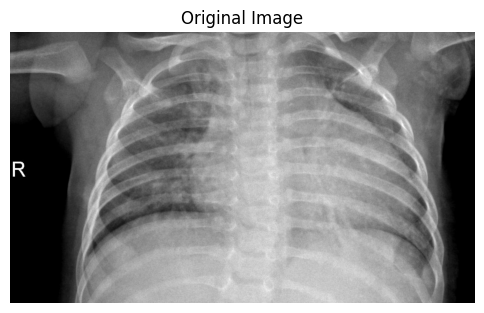

In [5]:
plt.figure(figsize=(6,6))
plt.imshow(image, cmap="gray")
plt.title("Original Image")
plt.axis("off")
plt.show()

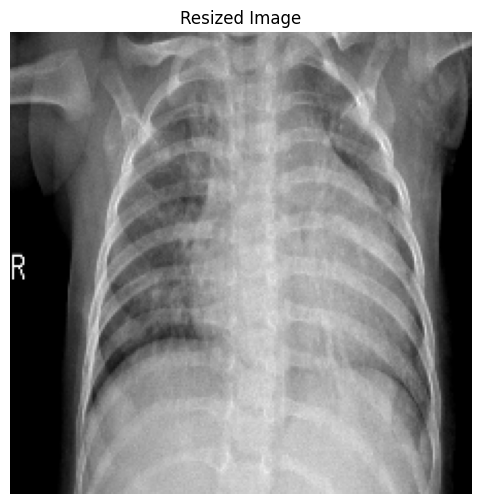

In [6]:
resized = cv2.resize(
    image,
    (224,224)
)

plt.figure(figsize=(6,6))
plt.imshow(resized, cmap="gray")
plt.title("Resized Image")
plt.axis("off")
plt.show()

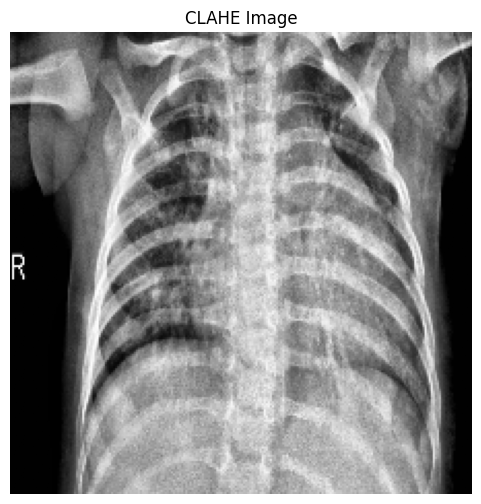

In [7]:
clahe = cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8,8)
)

clahe_img = clahe.apply(resized)

plt.figure(figsize=(6,6))
plt.imshow(clahe_img, cmap="gray")
plt.title("CLAHE Image")
plt.axis("off")
plt.show()

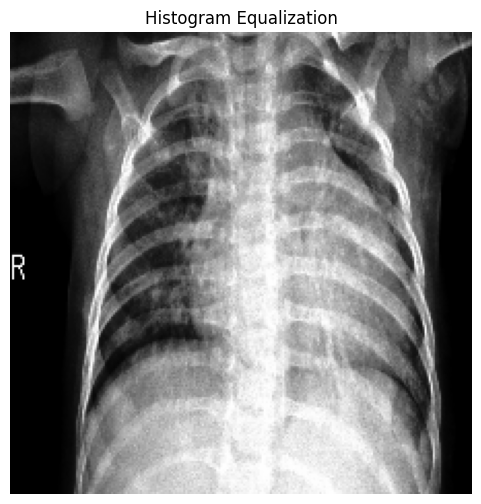

In [8]:
hist_eq = cv2.equalizeHist(resized)

plt.figure(figsize=(6,6))
plt.imshow(hist_eq, cmap="gray")
plt.title("Histogram Equalization")
plt.axis("off")
plt.show()

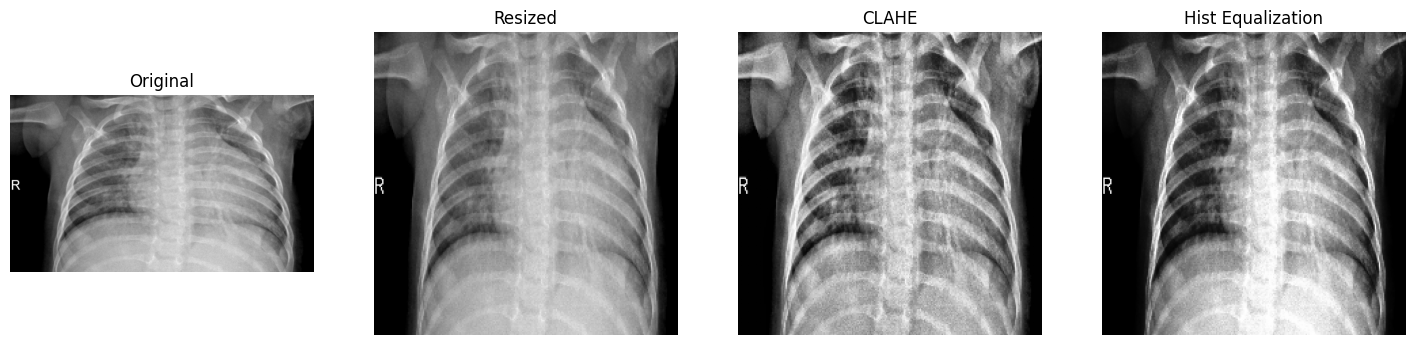

In [9]:
fig, axes = plt.subplots(
    1, 4,
    figsize=(18,5)
)

axes[0].imshow(image, cmap="gray")
axes[0].set_title("Original")

axes[1].imshow(resized, cmap="gray")
axes[1].set_title("Resized")

axes[2].imshow(clahe_img, cmap="gray")
axes[2].set_title("CLAHE")

axes[3].imshow(hist_eq, cmap="gray")
axes[3].set_title("Hist Equalization")

for ax in axes:
    ax.axis("off")

plt.show()

# Preprocessing Comparison Results

## Resize

Advantages:

- Standardized image dimensions
- Compatible with transfer learning architectures
- Reduced computational requirements

Decision:

✓ Required

---

## CLAHE

Advantages:

- Enhanced local contrast
- Improved visibility of lung structures
- Better representation of opacity regions
- Preserved anatomical information

Limitations:

- Slight increase in image noise

Decision:

✓ Strong candidate for final preprocessing pipeline

---

## Histogram Equalization

Advantages:

- Increased global contrast
- Improved visibility of certain structures

Limitations:

- More aggressive enhancement
- Potential over-amplification of bright regions
- Less natural appearance compared to CLAHE

Decision:

△ Alternative preprocessing option

---

## Final Preprocessing Decision

Selected Pipeline:

1. Convert to Grayscale
2. Resize to 224 × 224
3. Apply CLAHE
4. Normalize Pixel Values

Reasoning:

CLAHE provided the best balance between contrast enhancement and preservation of clinically relevant image features.

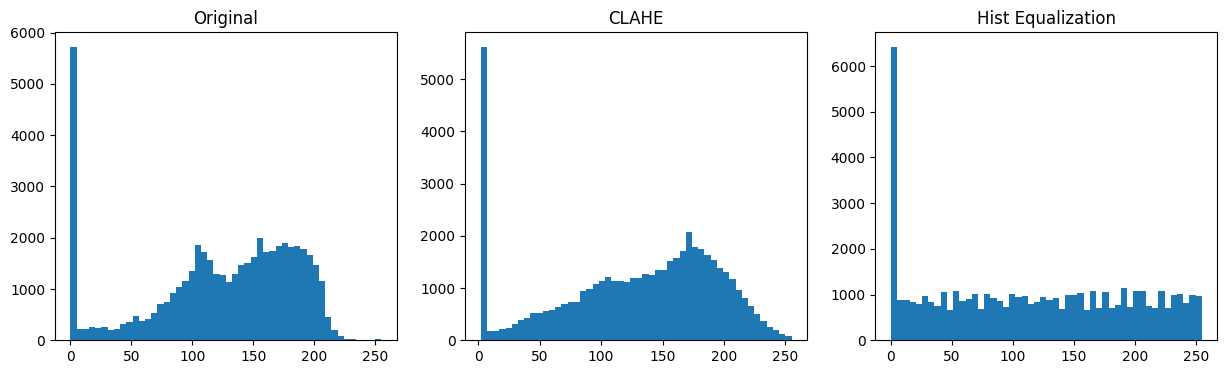

In [10]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(15,4)
)

axes[0].hist(
    resized.flatten(),
    bins=50
)
axes[0].set_title("Original")

axes[1].hist(
    clahe_img.flatten(),
    bins=50
)
axes[1].set_title("CLAHE")

axes[2].hist(
    hist_eq.flatten(),
    bins=50
)
axes[2].set_title("Hist Equalization")

plt.show()